<a href="https://colab.research.google.com/github/Emdejeee/PengolahanCitra/blob/main/Jobsheet%205.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Praktikum 1. Segmentasi Menggunakan Thresholding Global dan Otsu

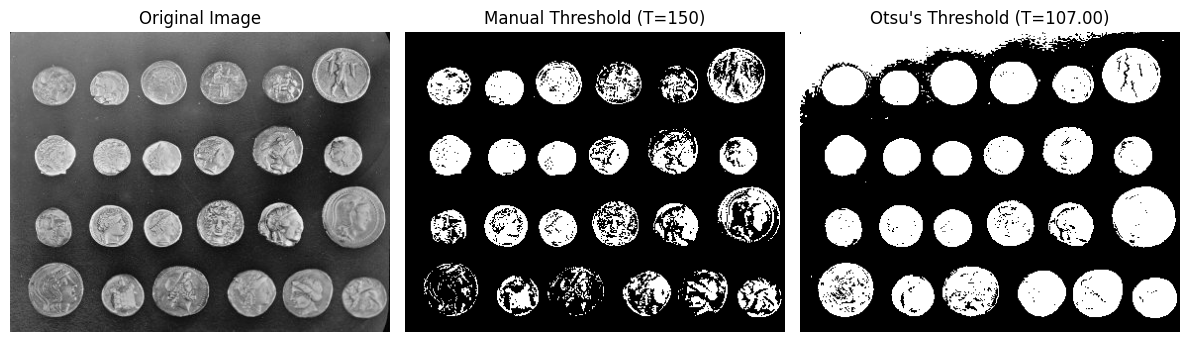

Nilai threshold Otsu yang ditemukan: 107


In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters, img_as_ubyte
from skimage.color import rgb2gray

# Memuat citra (contoh: coins)
image_coins = data.coins()  # Citra sudah grayscale

# Thresholding Global (manual)
thresh_manual = 150
binary_manual = image_coins > thresh_manual

# Thresholding Otsu
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

# Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_manual, cmap=plt.cm.gray)
ax[1].set_title(f'Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title(f'Otsu\'s Threshold (T={thresh_otsu:.2f})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

# Menampilkan nilai threshold Otsu
print(f"Nilai threshold Otsu yang ditemukan: {thresh_otsu}")

##Praktikum 2. Segmentasi Menggunakan Region Growing (Contoh Sederhana)

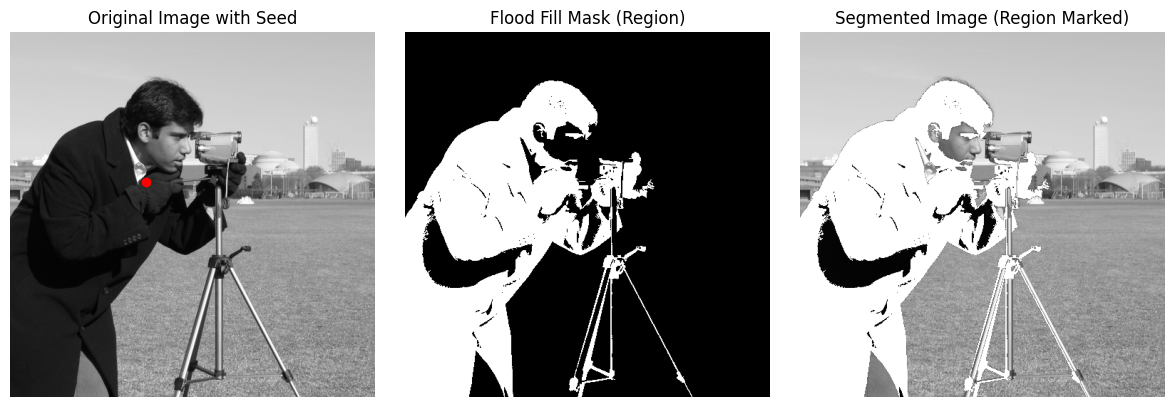

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation, color

# Memuat citra (contoh: camera)
image_camera = data.camera()

# Tentukan titik 'seed' (benih)
seed_point = (210, 190)

# Terapkan algoritma flood fill (mirip region growing)
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=40)

# Buat citra tersegmentasi (tandai region yang 'tumbuh')
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255  # Tandai region dengan warna putih

# Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap=plt.cm.gray)
ax[0].plot(seed_point[1], seed_point[0], 'ro')  # Tandai seed point
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

ax[1].imshow(flood_mask, cmap=plt.cm.gray)
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap=plt.cm.gray)
ax[2].set_title('Segmented Image (Region Marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

##Praktikum 3. Segmentasi Citra Berwarna Menggunakan K-Means Clustering

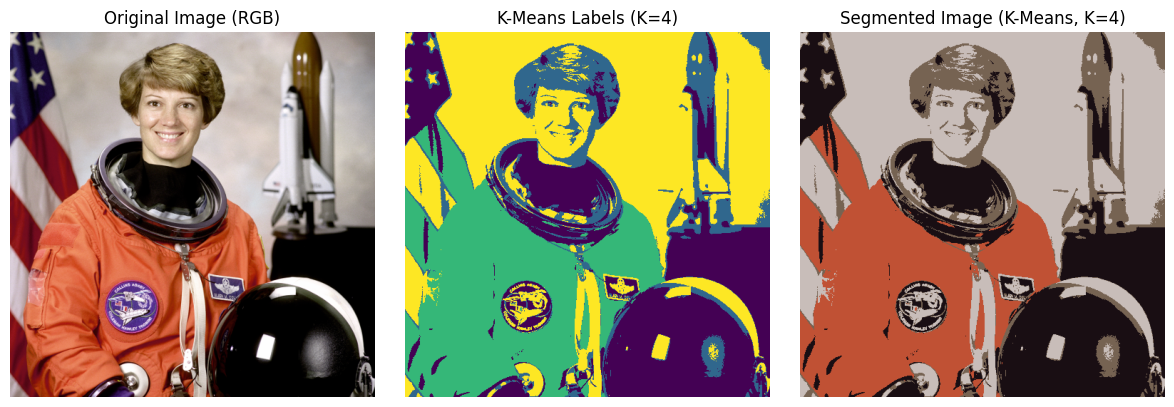

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.color import rgb2lab, lab2rgb
from sklearn.cluster import KMeans
import warnings

# 1. Load citra contoh (astronaut) dan konversi ke float
image = data.astronaut()
image_float = image.astype(float) / 255.0

# 2. Konversi ke ruang warna Lab (lebih sesuai untuk persepsi warna)
image_lab = rgb2lab(image_float)
rows, cols, channels = image_lab.shape
pixels = image_lab.reshape((-1, channels))

# 3. K-Means Clustering
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)

# Supresi peringatan terkait parameter default n_init
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    labels = kmeans.fit_predict(pixels)

# 4. Bentuk ulang label ke ukuran citra
labels_image = labels.reshape((rows, cols))

# 5. Buat citra hasil segmentasi berdasarkan pusat klaster
segmented_lab = np.zeros_like(image_lab)
for i in range(n_clusters):
    mask = (labels == i).reshape((rows, cols))
    segmented_lab[mask] = kmeans.cluster_centers_[i]

# Konversi kembali ke RGB
segmented_rgb = lab2rgb(segmented_lab)

# 6. Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image)
ax[0].set_title('Original Image (RGB)')
ax[0].axis('off')

ax[1].imshow(labels_image, cmap='viridis')
ax[1].set_title(f'K-Means Labels (K={n_clusters})')
ax[1].axis('off')

ax[2].imshow(segmented_rgb)
ax[2].set_title(f'Segmented Image (K-Means, K={n_clusters})')
ax[2].axis('off')

plt.tight_layout()
plt.show()


##Praktikum 4. Segmentasi Berbasis Tepi Menggunakan Watershed

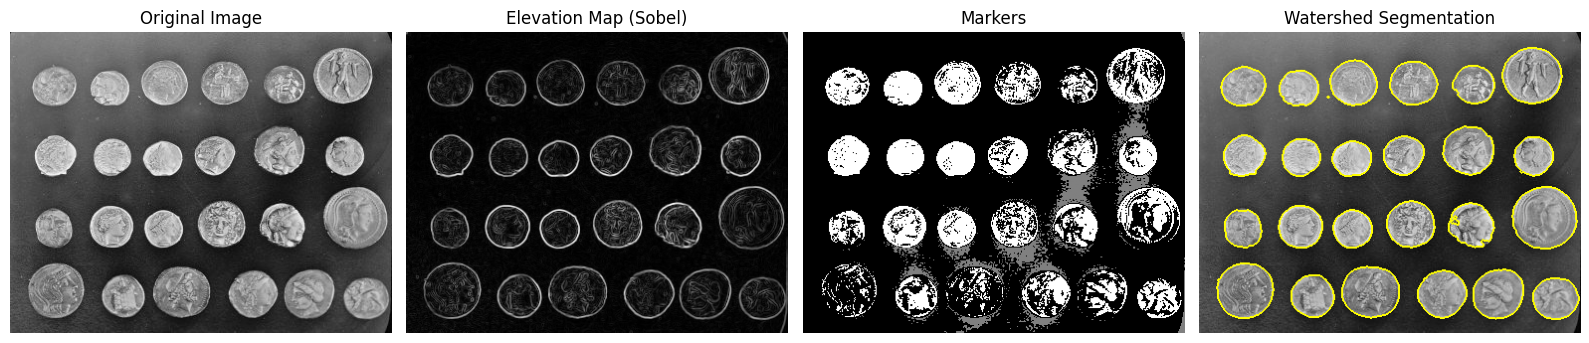

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, morphology, measure
from scipy import ndimage as ndi

# 1. Memuat citra contoh (koin)
image = data.coins()

# 2. Menghitung gradien Sobel sebagai representasi topografi
elevation_map = filters.sobel(image)

# 3. Menentukan marker menggunakan threshold sederhana
markers = np.zeros_like(image)
markers[image < 30] = 1     # Marker latar belakang
markers[image > 150] = 2    # Marker objek (koin)

# (Opsional) Alternatif menggunakan local maxima
# from skimage.feature import peak_local_max
# coordinates = peak_local_max(image, min_distance=20)
# mask = np.zeros(image.shape, dtype=bool)
# mask[tuple(coordinates.T)] = True
# markers = measure.label(mask)

# 4. Segmentasi dengan algoritma Watershed
segmentation_result = segmentation.watershed(elevation_map, markers)

# 5. Menandai batas hasil segmentasi untuk visualisasi
segmented_image = segmentation.mark_boundaries(image, segmentation_result)

# 6. Visualisasi semua tahap
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
titles = ['Original Image', 'Elevation Map (Sobel)', 'Markers', 'Watershed Segmentation']
images = [image, elevation_map, markers, segmented_image]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()


##Praktikum 5. Perbandingan Visual Hasil Segmentasi

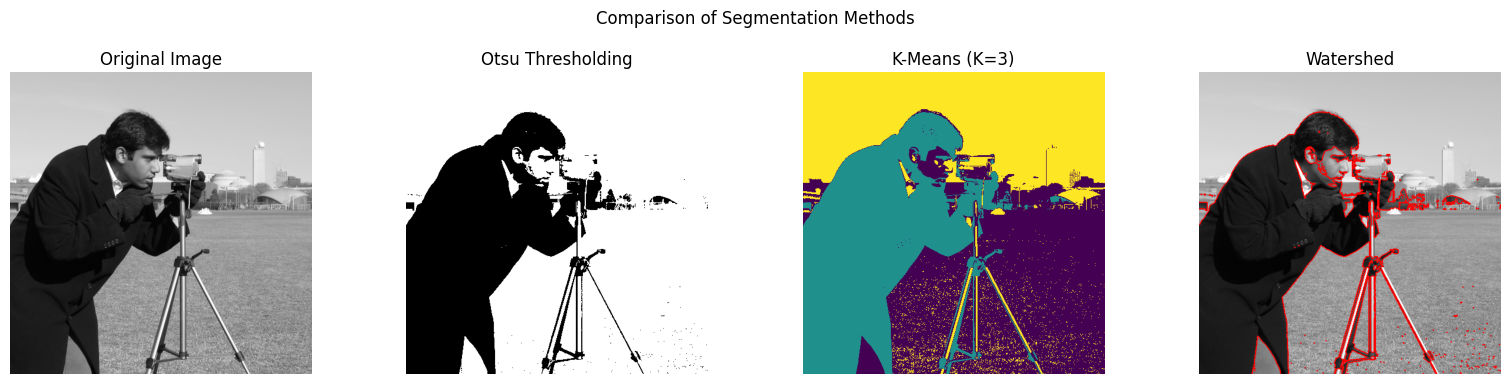

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import warnings
from skimage import data, filters, segmentation, img_as_float, color
from sklearn.cluster import KMeans

# 1. Ambil citra contoh (misalnya: kamera)
image = data.camera()
image_float = img_as_float(image)

# 2a. Segmentasi dengan Otsu Thresholding
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# 2b. Segmentasi dengan K-Means (K=3)
rows, cols = image.shape
pixel_features = image_float.reshape(rows * cols, 1)

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)

# Nonaktifkan warning selama fitting KMeans
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

# 2c. Segmentasi dengan Watershed menggunakan marker dari threshold Otsu
elevation_map = filters.sobel(image)
markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# 3. Visualisasi hasil segmentasi
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

# Gambar asli
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

# Hasil Otsu Thresholding
ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

# Hasil K-Means
ax[2].imshow(segmented_kmeans_labels, cmap='viridis')
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

# Hasil Watershed dengan batas ditandai
boundaries = segmentation.mark_boundaries(image_float, segmentation_watershed, color=(1, 0, 0))
ax[3].imshow(boundaries)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


##Tresholding


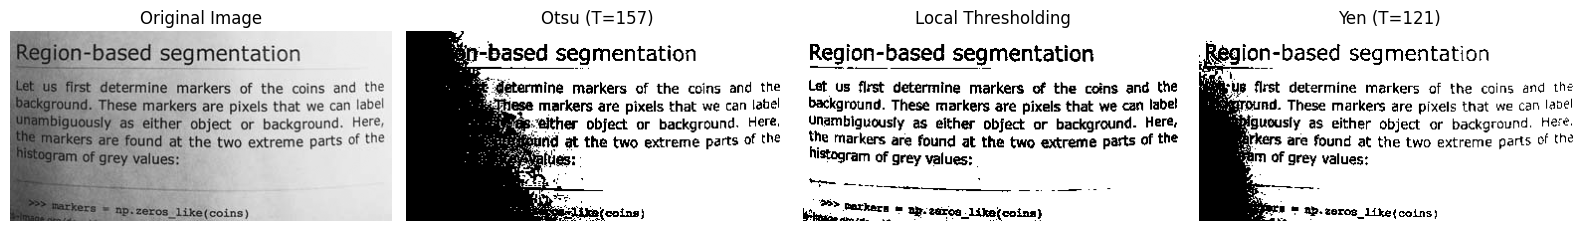

In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters
from skimage.filters import threshold_otsu, threshold_local, threshold_yen

# Memuat citra page
image_page = data.page()

# Thresholding Otsu
thresh_otsu = threshold_otsu(image_page)
binary_otsu = image_page > thresh_otsu

# Thresholding Lokal (Adaptive)
block_size = 115  # Ukuran blok untuk thresholding lokal
thresh_local = threshold_local(image_page, block_size, offset=10)
binary_local = image_page > thresh_local

# Thresholding Yen
thresh_yen = threshold_yen(image_page)
binary_yen = image_page > thresh_yen

# Visualisasi Hasil
fig, axes = plt.subplots(ncols=4, figsize=(16, 4))
ax = axes.ravel()

ax[0].imshow(image_page, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title(f'Otsu (T={thresh_otsu})')
ax[1].axis('off')

ax[2].imshow(binary_local, cmap=plt.cm.gray)
ax[2].set_title('Local Thresholding')
ax[2].axis('off')

ax[3].imshow(binary_yen, cmap=plt.cm.gray)
ax[3].set_title(f'Yen (T={thresh_yen})')
ax[3].axis('off')

plt.tight_layout()
plt.show()


##citra sederhana dari internet

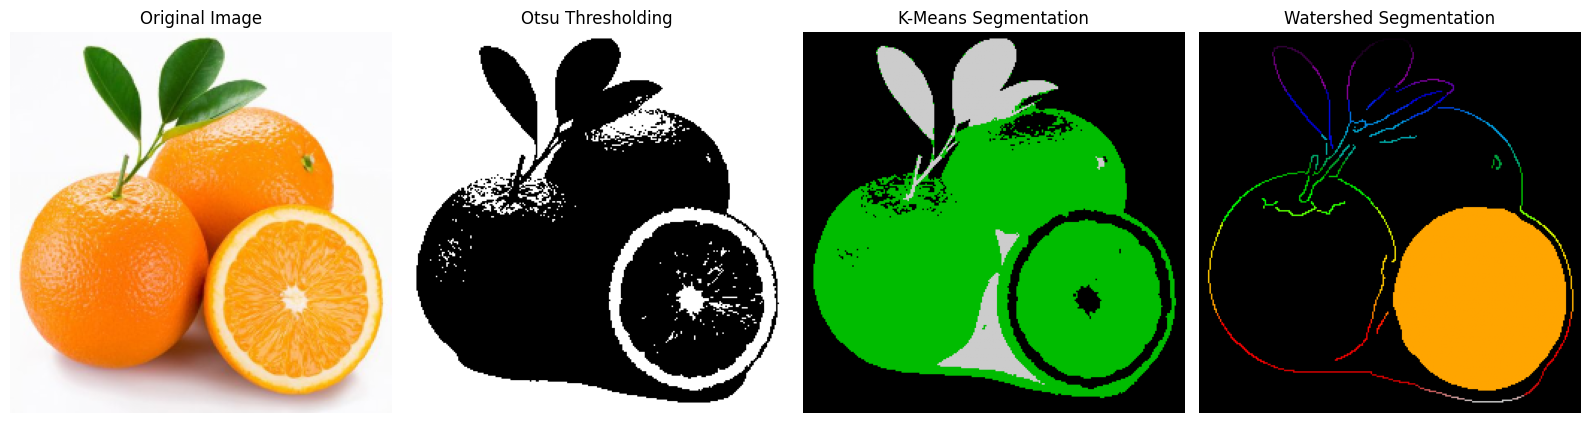

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters, morphology
from skimage.segmentation import watershed
from skimage.feature import canny
from scipy import ndimage as ndi
from sklearn.cluster import KMeans
from skimage.filters import threshold_otsu
from skimage.transform import resize

# Load image (gantilah 'buah.jpeg' sesuai nama file jika berbeda)
image = io.imread('buah.jpeg')
image_resized = resize(image, (256, 256), anti_aliasing=True)

# Convert to grayscale
gray = color.rgb2gray(image_resized)

# 1. Otsu Thresholding
thresh = threshold_otsu(gray)
binary_otsu = gray > thresh

# 2. K-Means Clustering
flat_image = image_resized.reshape(-1, 3)
kmeans = KMeans(n_clusters=3, random_state=42).fit(flat_image)
seg_kmeans = kmeans.labels_.reshape(image_resized.shape[:2])

# 3. Watershed Segmentation
edges = canny(gray, sigma=2.0)
fill_edges = ndi.binary_fill_holes(edges)
distance = ndi.distance_transform_edt(fill_edges)
local_max = morphology.local_maxima(distance)
markers, _ = ndi.label(local_max)
labels_ws = watershed(-distance, markers, mask=fill_edges)

# Plot results
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
axes[0].imshow(image_resized)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(binary_otsu, cmap='gray')
axes[1].set_title("Otsu Thresholding")
axes[1].axis('off')

axes[2].imshow(seg_kmeans, cmap='nipy_spectral')
axes[2].set_title("K-Means Segmentation")
axes[2].axis('off')

axes[3].imshow(labels_ws, cmap='nipy_spectral')
axes[3].set_title("Watershed Segmentation")
axes[3].axis('off')

plt.tight_layout()
plt.show()
